# Customer Churn Prediction

Objective:
To predict customer churn

## 1. Import Libraries

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

## 1. Load Dataset

In [24]:
df = pd.read_csv(r"E:\archive (2)\WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset loaded successfully.\n")
print("First 5 rows:")
df.head()

Dataset loaded successfully.

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Clean Dataset
The `customerID` column is removed because it does not help in prediction.  
`TotalCharges` is converted to numeric format, and missing values are removed.

In [25]:
df = df.drop("customerID", axis=1)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna()

print("After cleaning:")
df.info()

After cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null

In [26]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


## 3. Select Required Fields
The original dataset does not contain the exact fields mentioned in the assessment.  
So the following proxy mapping is used:

- Age → `tenure`
- Income → `MonthlyCharges`
- Purchases → `TotalCharges`
- Membership → `Contract`
- Churn → `Churn`

In [27]:
data = df[["tenure", "MonthlyCharges", "TotalCharges", "Contract", "Churn"]].copy()
data.columns = ["Age", "Income", "Purchases", "Membership", "Churn"]

print("Selected dataset:")
data.head()

Selected dataset:


,Age,Income,Purchases,Membership,Churn
0,1,29.85,29.85,Month-to-month,No
1,34,56.95,1889.50,One year,No
2,2,53.85,108.15,Month-to-month,Yes
3,45,42.30,1840.75,One year,No
4,2,70.70,151.65,Month-to-month,Yes


## 4. Convert Categorical Data
The `Membership` and `Churn` columns are categorical, so they are encoded into numeric values.

In [28]:
le_membership = LabelEncoder()
le_churn = LabelEncoder()

data["Membership"] = le_membership.fit_transform(data["Membership"])
data["Churn"] = le_churn.fit_transform(data["Churn"])

In [29]:
print("Membership Encoding Mapping:")
for i, label in enumerate(le_membership.classes_):
    print(f"{label} -> {i}")

print("\nChurn Encoding Mapping:")
for i, label in enumerate(le_churn.classes_):
    print(f"{label} -> {i}")

Membership Encoding Mapping:
Month-to-month -> 0
One year -> 1
Two year -> 2

Churn Encoding Mapping:
No -> 0
Yes -> 1


## 5. Define Features and Target
The independent variables are stored in `X`, and the target variable is stored in `y`.

In [30]:
X = data[["Age", "Income", "Purchases", "Membership"]]
y = data["Churn"]

X.head()

,Age,Income,Purchases,Membership
0,1,29.85,29.85,0
1,34,56.95,1889.50,1
2,2,53.85,108.15,0
3,45,42.30,1840.75,1
4,2,70.70,151.65,0


## 6. Train-Test Split
The dataset is split into training and testing sets.  
80% of the data is used for training and 20% for testing.

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train-test split completed successfully.")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Train-test split completed successfully.
X_train shape: (5625, 4)
X_test shape: (1407, 4)


## 7. Model 1 - Logistic Regression
Logistic Regression is used as a baseline classification model.

In [32]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", round(lr_acc, 4))
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.779
              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1033
           1       0.61      0.48      0.53       374

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.69      1407
weighted avg       0.77      0.78      0.77      1407



## 8. Model 2 - Random Forest
Random Forest is an ensemble learning method that combines multiple decision trees.

In [33]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", round(rf_acc, 4))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.764
              precision    recall  f1-score   support

           0       0.82      0.87      0.84      1033
           1       0.57      0.47      0.51       374

    accuracy                           0.76      1407
   macro avg       0.69      0.67      0.68      1407
weighted avg       0.75      0.76      0.76      1407



## 9. Model 3 - XGBoost
XGBoost is a boosting-based algorithm that performs well on structured tabular datasets.

In [34]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy:", round(xgb_acc, 4))
print(classification_report(y_test, xgb_pred))

XGBoost Accuracy: 0.7818
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.48      0.54       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407



## 10. Rule-Based Churn Logic
A simple business rule is created to compare manual logic with machine learning models.

In [35]:
def rule_based_churn(age, income, purchases, membership):
    if membership == 0 and purchases < 1000:
        return 1
    elif income > 70 and purchases < 500:
        return 1
    elif age < 6 and membership == 0:
        return 1
    else:
        return 0

In [36]:
rule_preds = X_test.apply(
    lambda row: rule_based_churn(
        row["Age"], row["Income"], row["Purchases"], row["Membership"]
    ),
    axis=1
)

rule_acc = accuracy_score(y_test, rule_preds)

print("Rule-Based Logic Accuracy:", round(rule_acc, 4))
print(classification_report(y_test, rule_preds))

Rule-Based Logic Accuracy: 0.7178
              precision    recall  f1-score   support

           0       0.83      0.78      0.80      1033
           1       0.47      0.56      0.51       374

    accuracy                           0.72      1407
   macro avg       0.65      0.67      0.66      1407
weighted avg       0.73      0.72      0.72      1407



## 11. Final Model Comparison
All models are compared based on accuracy, and the best model is identified.

In [37]:
scores = {
    "Logistic Regression": lr_acc,
    "Random Forest": rf_acc,
    "XGBoost": xgb_acc,
    "Rule-Based Logic": rule_acc
}

best_model = max(scores, key=scores.get)

if best_model == "Logistic Regression":
    reason = "It achieved the highest accuracy with a simple and interpretable structure."
elif best_model == "Random Forest":
    reason = "It achieved the highest accuracy and handled nonlinear feature interactions effectively."
elif best_model == "XGBoost":
    reason = "It achieved the highest accuracy and captured churn patterns most effectively."
else:
    reason = "It unexpectedly outperformed the machine learning models on this dataset split."

print("FINAL MODEL COMPARISON")
print(f"Logistic Regression Accuracy : {lr_acc:.4f}")
print(f"Random Forest Accuracy       : {rf_acc:.4f}")
print(f"XGBoost Accuracy             : {xgb_acc:.4f}")
print(f"Rule-Based Logic Accuracy    : {rule_acc:.4f}")

print(f"\nBest Model: {best_model}")
print(f"Reason: {reason}")

FINAL MODEL COMPARISON
Logistic Regression Accuracy : 0.7790
Random Forest Accuracy       : 0.7640
XGBoost Accuracy             : 0.7818
Rule-Based Logic Accuracy    : 0.7178

Best Model: XGBoost
Reason: It achieved the highest accuracy and captured churn patterns most effectively.


## 12. Feature Importance
Feature importance is displayed for the best tree-based model.

In [38]:
if best_model == "Random Forest":
    importances = rf_model.feature_importances_
elif best_model == "XGBoost":
    importances = xgb_model.feature_importances_
else:
    importances = None

if importances is not None:
    feature_importance_df = pd.DataFrame({
        "Feature": X.columns,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)

    print(feature_importance_df)
else:
    print("Feature importance not available for the selected best model.")

      Feature  Importance
3  Membership    0.851304
0         Age    0.061284
1      Income    0.052246
2   Purchases    0.035166


## 13. Save Results
The cleaned dataset and model comparison summary are saved as output files.

In [39]:
with open("model_comparison_summary.txt", "w") as f:
    f.write("Customer Churn Prediction - Model Comparison Summary\n")
    f.write("===================================================\n\n")
    f.write("Dataset Used: IBM Telco Customer Churn Dataset\n")
    f.write("Field Mapping:\n")
    f.write("Age -> tenure\n")
    f.write("Income -> MonthlyCharges\n")
    f.write("Purchases -> TotalCharges\n")
    f.write("Membership -> Contract\n")
    f.write("Churn -> Churn\n\n")

    f.write(f"Logistic Regression Accuracy : {lr_acc:.4f}\n")
    f.write(f"Random Forest Accuracy       : {rf_acc:.4f}\n")
    f.write(f"XGBoost Accuracy             : {xgb_acc:.4f}\n")
    f.write(f"Rule-Based Logic Accuracy    : {rule_acc:.4f}\n\n")

    f.write(f"Best Model: {best_model}\n")
    f.write(f"Reason: {reason}\n")

print("Summary saved as model_comparison_summary.txt")

Summary saved as model_comparison_summary.txt


In [40]:
data.to_csv("cleaned_churn_data.csv", index=False)
print("Cleaned dataset saved as cleaned_churn_data.csv")

Cleaned dataset saved as cleaned_churn_data.csv


## 14. Visualization
A bar chart is used to show the churn distribution.

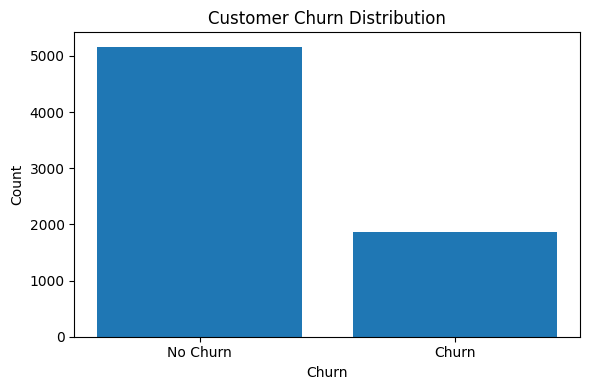

In [41]:
plt.figure(figsize=(6, 4))
churn_counts = data["Churn"].value_counts().sort_index()

plt.bar(["No Churn", "Churn"], churn_counts.values)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 15. Conclusion

Among the tested algorithms, **XGBoost** achieved the highest accuracy of **78.18%**.  
This indicates that boosting-based methods are more effective in capturing churn patterns in structured customer datasets.

The rule-based model performed lower than the machine learning models, showing that fixed rules are less adaptive than data-driven approaches.